In [ ]:
!pip install kaggle -q

In [ ]:
from google.colab import files
uploaded = files.upload()  # select your kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 85% 138M/163M [00:00<00:00, 1.44GB/s]
100% 163M/163M [00:00<00:00, 1.29GB/s]


In [9]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print(' The dataset is extracted')

 The dataset is extracted


In [10]:
import os

In [ ]:
with_mask_dir = '/content/data/with_mask'
filenames_with_mask = os.listdir(with_mask_dir)
num_of_with_mask = len(filenames_with_mask)
print('Number of images with mask:', num_of_with_mask)

In [ ]:
without_mask_dir = '/content/data/without_mask'
filenames_without_mask = os.listdir(without_mask_dir)
num_of_without_mask = len(filenames_without_mask)
print('Number of images without mask:', num_of_without_mask)

Number of images with mask: 3725


In [ ]:
import numpy as np
import cv2
import glob
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

with mask --> 1
without mask --> 0

In [ ]:
with_mask_labels = [1]*num_of_with_mask
print(with_mask_labels)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [ ]:
without_mask_labels = [0]*num_of_without_mask
print(without_mask_labels)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [19]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [20]:
labels = with_mask_labels + without_mask_labels
print(len(labels))

7553


In [21]:
print(labels)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

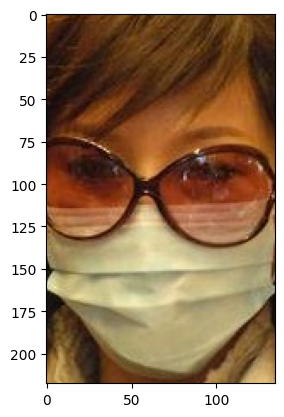

In [ ]:
img = mpimg.imread(os.path.join(with_mask_dir, filenames_with_mask[0]))
plt.imshow(img)
plt.title('With mask (sample)')
plt.show()

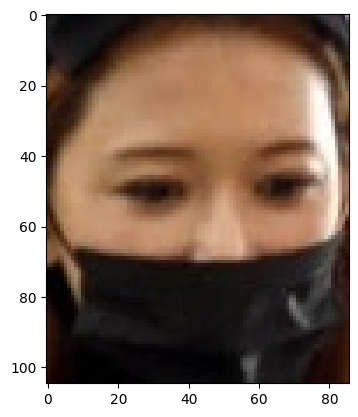

In [ ]:
img = mpimg.imread(os.path.join(without_mask_dir, filenames_without_mask[0]))
plt.imshow(img)
plt.title('Without mask (sample)')
plt.show()

In [ ]:
IMG_SIZE = 128

os.makedirs('with_mask_resized', exist_ok=True)
os.makedirs('without_mask_resized', exist_ok=True)

with_mask_resized_folder = '/content/with_mask_resized/'
without_mask_resized_folder = '/content/without_mask_resized/'

def resize_and_save(src_folder, dst_folder):
    for filename in os.listdir(src_folder):
        img_path = os.path.join(src_folder, filename)
        try:
            img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            img.save(os.path.join(dst_folder, filename))
        except Exception as e:
            print(f'Skipping {filename}: {e}')

resize_and_save(with_mask_dir, with_mask_resized_folder)
resize_and_save(without_mask_dir, without_mask_resized_folder)

print('Resizing done')

In [ ]:
def load_images(folder):
    files_list = []
    for ext in ('*.png', '*.jpg', '*.jpeg'):
        files_list.extend(glob.glob(os.path.join(folder, ext)))
    images = []
    for f in files_list:
        img = cv2.imread(f)
        if img is not None:
            images.append(img)
    return np.asarray(images)

with_mask_images = load_images(with_mask_resized_folder)
without_mask_images = load_images(without_mask_resized_folder)

print(with_mask_images.shape, without_mask_images.shape)

In [ ]:
X = np.concatenate((with_mask_images, without_mask_images))
Y = np.asarray(labels[:len(X)])  # safety: match length in case a few images failed to load

print('X shape:', X.shape)
print('Y shape:', Y.shape)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2, stratify=Y
)

print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

In [ ]:
X_train_std = X_train.astype('float32') / 255.0
X_test_std = X_test.astype('float32') / 255.0

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')  # single output: probability of "with mask"
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
history = model.fit(
    X_train_std, Y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

In [ ]:
score, acc = model.evaluate(X_test_std, Y_test)
print('Test data loss:', score)
print('Test data accuracy:', acc)

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
def predict_mask(image_path, model, img_size=IMG_SIZE, threshold=0.5):
    input_image = cv2.imread(image_path)
    if input_image is None:
        raise ValueError(f'Could not read image at {image_path}')

    resized = cv2.resize(input_image, (img_size, img_size))
    normalized = resized.astype('float32') / 255.0
    batch = np.expand_dims(normalized, axis=0)  # shape (1, 128, 128, 3)

    prob_with_mask = model.predict(batch)[0][0]
    label = 1 if prob_with_mask >= threshold else 0

    print(f'Predicted probability of wearing a mask: {prob_with_mask:.4f}')
    if label == 1:
        print('The person is wearing a mask')
    else:
        print('The person is NOT wearing a mask')

    return label, prob_with_mask

In [ ]:
input_image_path = input('Path of the image to be predicted: ')
predict_mask(input_image_path, model)

In [ ]:
input_image_path = input('Path of the image to be predicted: ')
predict_mask(input_image_path, model)